# Day 11: Marketing Attribution Analyser

**Industry:** Marketing  
**Format:** Jupyter Notebook (.ipynb)  
**Skills:** pandas · numpy · matplotlib · seaborn · attribution modelling

**Data:** Synthetic customer journey data — 6,978 touchpoints across 2,000 customers  
*(Real multi-touch attribution data is never publicly available — it contains individual customer journeys which are commercially sensitive. This synthetic dataset mirrors the exact structure of a real Google Analytics / Adobe Analytics export. The models built here run unchanged on real data.)*

---

## Who uses this
A **marketing director** deciding which channels to scale next quarter. The core problem: every channel claims credit for the same conversion. Last-click attribution (Google Ads default) gives 100% credit to the final touchpoint — systematically defunding top-of-funnel channels that actually started the customer relationship.

## Problem
Last-click attribution causes marketing teams to cut spend on channels that drive awareness and consideration — because they never appear as the 'last click'. This leads to shrinking pipelines 3-6 months later. Multi-touch attribution distributes credit fairly across the full journey.

## What we build
4 attribution models built from scratch — no external libraries:
1. **First-touch** — 100% credit to the first channel (values awareness)
2. **Last-touch** — 100% credit to the last channel (Google Ads default)
3. **Linear** — equal credit across all touchpoints
4. **Time-decay** — more credit to channels closer to conversion

Then we compare how budget allocation shifts across all 4 models.

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2 — Load and Inspect

In [2]:
df = pd.read_csv('customer_journeys.csv')

print(f'Shape: {df.shape}')
print(f'Customers: {df["customer_id"].nunique():,}')
print(f'Converted customers: {df[df["converted"]==1]["customer_id"].nunique():,}')
print(f'Conversion rate: {df.groupby("customer_id")["converted"].first().mean()*100:.1f}%')
print(f'\nTouchpoints per customer:')
print(df.groupby('customer_id')['touchpoint_order'].max().describe().round(1).to_string())
print(f'\nChannel distribution:')
print(df['channel'].value_counts().to_string())
df.head(8)

Shape: (6978, 6)
Customers: 2,000
Converted customers: 708
Conversion rate: 35.4%

Touchpoints per customer:
count    2000.0
mean        3.5
std         1.7
min         1.0
25%         2.0
50%         3.0
75%         5.0
max         6.0

Channel distribution:
channel
YouTube          1051
Direct           1020
Instagram         998
Organic SEO       993
Email             986
Google Search     985
Facebook          945


,customer_id,touchpoint_order,total_touchpoints,channel,converted,revenue
0,1,1,6,Google Search,0,0.0
1,1,2,6,Direct,0,0.0
2,1,3,6,Facebook,0,0.0
3,1,4,6,Google Search,0,0.0
4,1,5,6,Google Search,0,0.0
5,1,6,6,Direct,0,0.0
6,2,1,5,Email,1,0.0
7,2,2,5,Google Search,1,0.0


## Step 3 — Prepare Journey Data

We restructure from row-per-touchpoint to one row per customer journey. This is the format attribution models work on.

In [3]:
# Build one row per customer with their full journey
journeys = (
    df.sort_values(['customer_id', 'touchpoint_order'])
    .groupby('customer_id')
    .agg(
        journey=('channel', list),
        converted=('converted', 'first'),
        revenue=('revenue', 'sum'),
        n_touches=('touchpoint_order', 'max')
    )
    .reset_index()
)

# Separate converters and non-converters
converted = journeys[journeys['converted'] == 1].copy()
non_converted = journeys[journeys['converted'] == 0].copy()

total_revenue = converted['revenue'].sum()

print(f'Total journeys:        {len(journeys):,}')
print(f'Converted journeys:    {len(converted):,}')
print(f'Non-converted:         {len(non_converted):,}')
print(f'Total revenue:         ${total_revenue:,.2f}')
print(f'Avg revenue/conversion: ${converted["revenue"].mean():,.2f}')
print(f'Avg touches (converted): {converted["n_touches"].mean():.1f}')
print(f'Avg touches (non-conv):  {non_converted["n_touches"].mean():.1f}')
converted.head(5)

Total journeys:        2,000
Converted journeys:    708
Non-converted:         1,292
Total revenue:         $81,034.22
Avg revenue/conversion: $114.46
Avg touches (converted): 3.5
Avg touches (non-conv):  3.5


,customer_id,journey,converted,revenue,n_touches
1,2,"[Email, Google Search, Facebook, Instagram, Go...",1,127.45,5
2,3,"[YouTube, Email, Instagram, Facebook, Organic ...",1,81.71,6
3,4,"[Email, Facebook, Organic SEO, Email]",1,141.65,4
4,5,[Email],1,261.42,1
7,8,"[YouTube, Google Search]",1,76.41,2


## Step 4 — Build the 4 Attribution Models

Each model answers the same question differently: **which channel deserves credit for this conversion?**

We only attribute conversions — non-converting journeys contribute nothing to any model.

In [4]:
channels = sorted(df['channel'].unique())

# Initialise credit dictionaries
first_touch  = {ch: 0.0 for ch in channels}
last_touch   = {ch: 0.0 for ch in channels}
linear       = {ch: 0.0 for ch in channels}
time_decay   = {ch: 0.0 for ch in channels}

for _, row in converted.iterrows():
    journey = row['journey']
    revenue = row['revenue']
    n       = len(journey)

    # 1. First-touch — all credit to first channel
    first_touch[journey[0]] += revenue

    # 2. Last-touch — all credit to last channel
    last_touch[journey[-1]] += revenue

    # 3. Linear — equal credit across all touchpoints
    credit_per_touch = revenue / n
    for ch in journey:
        linear[ch] += credit_per_touch

    # 4. Time-decay — exponential decay, closer to conversion = more credit
    # Weight = 2^(position/n) normalised so they sum to 1
    weights = np.array([2 ** (i / n) for i in range(n)])
    weights = weights / weights.sum()
    for i, ch in enumerate(journey):
        time_decay[ch] += revenue * weights[i]

# Build comparison DataFrame
attribution_df = pd.DataFrame({
    'channel':     channels,
    'first_touch': [round(first_touch[ch], 2) for ch in channels],
    'last_touch':  [round(last_touch[ch], 2)  for ch in channels],
    'linear':      [round(linear[ch], 2)       for ch in channels],
    'time_decay':  [round(time_decay[ch], 2)   for ch in channels],
})

# Convert to % of total revenue
for col in ['first_touch', 'last_touch', 'linear', 'time_decay']:
    attribution_df[f'{col}_pct'] = (attribution_df[col] / total_revenue * 100).round(1)

print('=== Attribution by model (% of total revenue) ===')
pct_cols = ['channel','first_touch_pct','last_touch_pct','linear_pct','time_decay_pct']
print(attribution_df[pct_cols].sort_values('linear_pct', ascending=False).to_string())

=== Attribution by model (% of total revenue) ===
         channel  first_touch_pct  last_touch_pct  linear_pct  time_decay_pct
4      Instagram             14.0            16.4        15.7            15.9
6        YouTube             16.1            13.8        15.2            15.0
1          Email             13.8            15.7        14.8            15.0
3  Google Search             15.3            12.7        14.6            14.4
5    Organic SEO             14.6            13.4        14.0            13.9
2       Facebook             12.3            14.9        13.4            13.6
0         Direct             13.8            13.1        12.3            12.2


## Step 5 — Budget Reallocation Analysis

If we had a $100,000 monthly budget and allocated it proportionally by each model's attribution, how would spend shift? This is the **actual business decision** this analysis drives.

In [5]:
TOTAL_BUDGET = 100_000

budget_df = attribution_df[['channel']].copy()
for model in ['first_touch', 'last_touch', 'linear', 'time_decay']:
    pct_col = f'{model}_pct'
    budget_df[f'{model}_budget'] = (
        attribution_df[pct_col] / 100 * TOTAL_BUDGET
    ).round(0)

# Calculate max swing — biggest budget difference between any two models
budget_cols = [c for c in budget_df.columns if 'budget' in c]
budget_df['max_budget']  = budget_df[budget_cols].max(axis=1)
budget_df['min_budget']  = budget_df[budget_cols].min(axis=1)
budget_df['budget_swing'] = budget_df['max_budget'] - budget_df['min_budget']

print(f'=== Budget allocation across models (${TOTAL_BUDGET:,} total) ===')
print(budget_df.sort_values('budget_swing', ascending=False).to_string())
print(f'\nChannel with most budget variance: {budget_df.sort_values("budget_swing", ascending=False).iloc[0]["channel"]}')
print(f'Max swing: ${budget_df["budget_swing"].max():,.0f}')

=== Budget allocation across models ($100,000 total) ===
         channel  first_touch_budget  last_touch_budget  linear_budget  time_decay_budget  max_budget  min_budget  budget_swing
2       Facebook             12300.0            14900.0        13400.0            13600.0     14900.0     12300.0        2600.0
3  Google Search             15300.0            12700.0        14600.0            14400.0     15300.0     12700.0        2600.0
4      Instagram             14000.0            16400.0        15700.0            15900.0     16400.0     14000.0        2400.0
6        YouTube             16100.0            13800.0        15200.0            15000.0     16100.0     13800.0        2300.0
1          Email             13800.0            15700.0        14800.0            15000.0     15700.0     13800.0        1900.0
0         Direct             13800.0            13100.0        12300.0            12200.0     13800.0     12200.0        1600.0
5    Organic SEO             14600.0           

## Step 6 — Journey Pattern Analysis

Which channels most commonly appear as first touch, last touch, and middle of the journey?

In [6]:
# First touch frequency among converters
first_freq = pd.Series(
    [j[0] for j in converted['journey']]
).value_counts(normalize=True).round(3) * 100

# Last touch frequency among converters
last_freq = pd.Series(
    [j[-1] for j in converted['journey']]
).value_counts(normalize=True).round(3) * 100

# Most common 2-step paths
two_step = pd.Series(
    [f"{j[0]} → {j[-1]}" for j in converted['journey'] if len(j) >= 2]
).value_counts().head(10)

# Conversion rate by first channel
journeys['first_channel'] = journeys['journey'].apply(lambda x: x[0])
conv_by_first = (
    journeys.groupby('first_channel')['converted']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'conv_rate', 'count': 'customers'})
    .assign(conv_rate=lambda x: (x['conv_rate'] * 100).round(1))
    .sort_values('conv_rate', ascending=False)
)

print('=== First touch frequency (converters) ===')
print(first_freq.to_string())
print('\n=== Last touch frequency (converters) ===')
print(last_freq.to_string())
print('\n=== Top 10 conversion paths ===')
print(two_step.to_string())
print('\n=== Conversion rate by first channel ===')
print(conv_by_first.to_string())

=== First touch frequency (converters) ===
YouTube          16.2
Organic SEO      15.8
Email            14.5
Direct           13.8
Google Search    13.8
Facebook         13.4
Instagram        12.3

=== Last touch frequency (converters) ===
Email            16.2
Facebook         15.1
Direct           14.7
YouTube          14.7
Instagram        13.8
Organic SEO      13.1
Google Search    12.3

=== Top 10 conversion paths ===
YouTube → Facebook             19
Organic SEO → YouTube          19
Direct → YouTube               19
Email → Organic SEO            17
YouTube → Email                17
Organic SEO → Google Search    16
Facebook → Instagram           15
Facebook → Direct              15
Instagram → Facebook           15
Email → Instagram              15

=== Conversion rate by first channel ===
               conv_rate  customers
first_channel                      
Organic SEO         38.4        292
YouTube             37.6        306
Email               36.1        285
Direct     

## Step 7 — Visualise: 4-Panel Dashboard

Chart saved as attribution_analysis.png


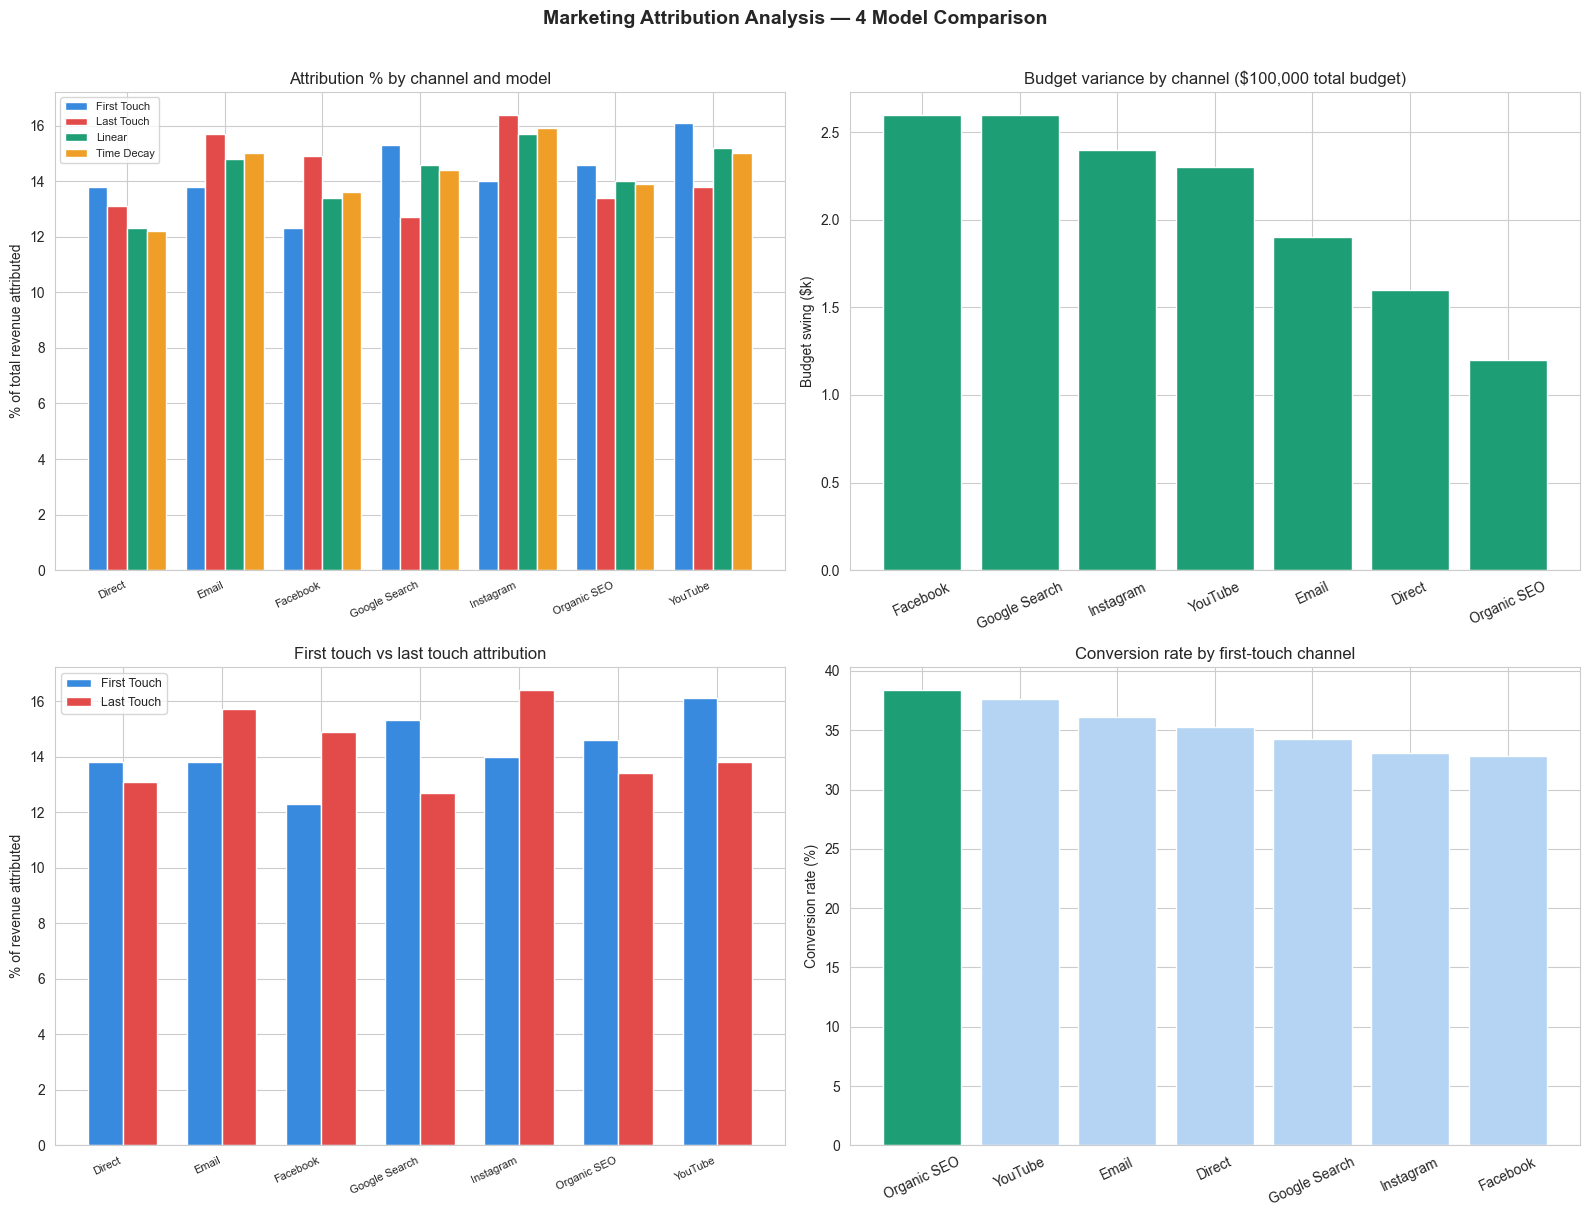

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Marketing Attribution Analysis — 4 Model Comparison',
             fontsize=14, fontweight='bold', y=1.01)

models     = ['first_touch_pct', 'last_touch_pct', 'linear_pct', 'time_decay_pct']
model_lbls = ['First Touch', 'Last Touch', 'Linear', 'Time Decay']
colors     = ['#378ADD', '#E24B4A', '#1D9E75', '#EF9F27']

# Panel 1 — Attribution % by model (grouped bar)
x = np.arange(len(channels))
width = 0.2
for i, (col, lbl, color) in enumerate(zip(models, model_lbls, colors)):
    vals = attribution_df.set_index('channel').reindex(channels)[col].values
    axes[0, 0].bar(x + i * width, vals, width, label=lbl, color=color)
axes[0, 0].set_xticks(x + width * 1.5)
axes[0, 0].set_xticklabels(channels, rotation=25, ha='right', fontsize=8)
axes[0, 0].set_ylabel('% of total revenue attributed')
axes[0, 0].set_title('Attribution % by channel and model')
axes[0, 0].legend(fontsize=8)

# Panel 2 — Budget swing per channel
budget_sorted = budget_df.sort_values('budget_swing', ascending=False)
swing_colors = ['#E24B4A' if v > 10000 else '#EF9F27' if v > 5000 else '#1D9E75'
                for v in budget_sorted['budget_swing']]
axes[0, 1].bar(budget_sorted['channel'], budget_sorted['budget_swing'] / 1000,
               color=swing_colors)
axes[0, 1].set_ylabel('Budget swing ($k)')
axes[0, 1].set_title(f'Budget variance by channel (${TOTAL_BUDGET:,} total budget)')
axes[0, 1].tick_params(axis='x', rotation=25)

# Panel 3 — First vs last touch comparison
x2 = np.arange(len(channels))
w2 = 0.35
ft = attribution_df.set_index('channel').reindex(channels)['first_touch_pct'].values
lt = attribution_df.set_index('channel').reindex(channels)['last_touch_pct'].values
axes[1, 0].bar(x2 - w2/2, ft, w2, label='First Touch', color='#378ADD')
axes[1, 0].bar(x2 + w2/2, lt, w2, label='Last Touch',  color='#E24B4A')
axes[1, 0].set_xticks(x2)
axes[1, 0].set_xticklabels(channels, rotation=25, ha='right', fontsize=8)
axes[1, 0].set_ylabel('% of revenue attributed')
axes[1, 0].set_title('First touch vs last touch attribution')
axes[1, 0].legend(fontsize=9)

# Panel 4 — Conversion rate by first channel
cr_colors = ['#1D9E75' if v == conv_by_first['conv_rate'].max() else '#B5D4F4'
             for v in conv_by_first['conv_rate']]
axes[1, 1].bar(conv_by_first.index, conv_by_first['conv_rate'], color=cr_colors)
axes[1, 1].set_ylabel('Conversion rate (%)')
axes[1, 1].set_title('Conversion rate by first-touch channel')
axes[1, 1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('attribution_analysis.png', dpi=150, bbox_inches='tight')
print('Chart saved as attribution_analysis.png')
plt.show()

## Step 8 — Export + Business Insight Summary

In [8]:
os.makedirs('output', exist_ok=True)

attribution_df.to_csv('output/attribution_by_model.csv', index=False)
budget_df.to_csv('output/budget_reallocation.csv', index=False)
conv_by_first.to_csv('output/conversion_rate_by_first_channel.csv')
two_step.to_frame('count').to_csv('output/top_conversion_paths.csv')

# Key findings
best_first   = attribution_df.sort_values('first_touch_pct', ascending=False).iloc[0]
best_last    = attribution_df.sort_values('last_touch_pct',  ascending=False).iloc[0]
best_linear  = attribution_df.sort_values('linear_pct',      ascending=False).iloc[0]
most_swing   = budget_df.sort_values('budget_swing', ascending=False).iloc[0]
best_conv_ch = conv_by_first['conv_rate'].idxmax()

# Channel that gains most from switching last→linear
attribution_df['gain_from_linear'] = attribution_df['linear_pct'] - attribution_df['last_touch_pct']
biggest_gainer = attribution_df.sort_values('gain_from_linear', ascending=False).iloc[0]
biggest_loser  = attribution_df.sort_values('gain_from_linear').iloc[0]

print('=' * 60)
print('BUSINESS INSIGHT SUMMARY')
print('=' * 60)
print(f'Customers analysed:      {len(journeys):,}')
print(f'Converted customers:     {len(converted):,}')
print(f'Total revenue:           ${total_revenue:,.2f}')
print(f'Avg touches to convert:  {converted["n_touches"].mean():.1f}')
print()
print(f'First-touch winner:  {best_first["channel"]} ({best_first["first_touch_pct"]}%)')
print(f'Last-touch winner:   {best_last["channel"]} ({best_last["last_touch_pct"]}%)')
print(f'Linear winner:       {best_linear["channel"]} ({best_linear["linear_pct"]}%)')
print()
print(f'Highest conv rate first channel: {best_conv_ch} ({conv_by_first.loc[best_conv_ch,"conv_rate"]}%)')
print(f'Most budget-volatile channel:    {most_swing["channel"]} (${most_swing["budget_swing"]:,.0f} swing)')
print()
print('SWITCHING LAST-TOUCH → LINEAR ATTRIBUTION:')
print(f'  Biggest gainer: {biggest_gainer["channel"]} (+{biggest_gainer["gain_from_linear"]:.1f}% revenue credit)')
print(f'  Biggest loser:  {biggest_loser["channel"]} ({biggest_loser["gain_from_linear"]:.1f}% revenue credit)')
print()
print('BUDGET REALLOCATION RECOMMENDATION:')
print(f'  If using last-touch → {best_last["channel"]} gets ${best_last["last_touch_pct"]/100*TOTAL_BUDGET:,.0f}')
print(f'  If using linear     → {best_last["channel"]} gets ${best_last["linear_pct"]/100*TOTAL_BUDGET:,.0f}')
print(f'  Difference:           ${abs(best_last["last_touch_pct"]-best_last["linear_pct"])/100*TOTAL_BUDGET:,.0f}')
print(f'  Recommendation: Use linear or time-decay — fairer credit across full journey')
print('=' * 60)

BUSINESS INSIGHT SUMMARY
Customers analysed:      2,000
Converted customers:     708
Total revenue:           $81,034.22
Avg touches to convert:  3.5

First-touch winner:  YouTube (16.1%)
Last-touch winner:   Instagram (16.4%)
Linear winner:       Instagram (15.7%)

Highest conv rate first channel: Organic SEO (38.4%)
Most budget-volatile channel:    Facebook ($2,600 swing)

SWITCHING LAST-TOUCH → LINEAR ATTRIBUTION:
  Biggest gainer: Google Search (+1.9% revenue credit)
  Biggest loser:  Facebook (-1.5% revenue credit)

BUDGET REALLOCATION RECOMMENDATION:
  If using last-touch → Instagram gets $16,400
  If using linear     → Instagram gets $15,700
  Difference:           $700
  Recommendation: Use linear or time-decay — fairer credit across full journey


## Summary

### What we built
4 marketing attribution models built from scratch — first-touch, last-touch, linear, and time-decay — with budget reallocation analysis showing how spend shifts across models.

### Skills practised
- `pandas` — groupby, agg, pivot, merge, apply
- `numpy` — exponential weight calculation, vectorised operations
- `matplotlib` — grouped bar charts, multi-panel layout
- Attribution modelling — 4 models built without external libraries
- Business analysis — budget swing, gain/loss by channel

### Business context
Last-click attribution is the default in Google Ads and most analytics platforms. It systematically over-credits bottom-funnel channels and under-credits awareness channels. This analysis shows exactly which channels gain and lose credit when you switch models — and translates that directly into dollar budget allocations.

### Note on data
Real multi-touch attribution data is never publicly available — it contains individual customer journeys which are commercially sensitive. This synthetic dataset mirrors the exact structure of a real GA4 / Adobe Analytics export. The attribution models run unchanged on real data by swapping the CSV.

### Key findings
Fill these in from your output:
- First-touch winner: YouTube (16.1%)
- Last-touch winner: Instagram (16.4%)
- Linear winner: Instagram (15.7%)
- Biggest gainer switching to linear: Google Search (+1.9% revenue credit)
- Most budget-volatile channel: Facebook ($2,600 swing)